In [117]:
# import scvelo as scv
from multiprocessing import Pool

import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

In [118]:
import mudata as mu

In [119]:
import os
from functools import partial
from pathlib import Path
from typing import Optional

import altair as alt

# Libraries
import anndata as ad
import decoupler as dc
import matplotlib as plt
import mudata as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir
import seaborn as sns
from anndata import AnnData
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation

alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir
import scipy.sparse as sp

## 2 · Data Loading

Load mudata

In [111]:
#mdata = mu.read_h5mu("001_create_mudata_normal.h5mu")

In [112]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/001_create_mudata_normal.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [129]:

#mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/002_annotate_mudata_normal.h5mu")

#adata = mdata["gex"]

#adata.write_h5ad("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/002_annotate_adata_normal.h5ad")

In [128]:
mdata

MuData object with n_obs × n_vars = 18315 × 18038
  3 modalities
    gex:	18263 x 18038
      obs:	'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_2', 'rna_leiden_colors', 'sample_id_colors', 'scrublet', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    airr:	15207 x 0
      obsm:	'airr'
    adt:	15207 x 0
      obs:	'sample_id'
      var:	'gene_ids', 'feature_types'

In [10]:
mdata["gex"].obs.condition

AAACCTGAGTCTTGCA-1_10mix1    ctrl
AAACCTGAGTTAAGTG-1_10mix1    ctrl
AAACCTGCAGGATCGA-1_10mix1    ctrl
AAACCTGCATAACCTG-1_10mix1    ctrl
AAACCTGCATACCATG-1_10mix1    ctrl
                             ... 
TTTGCGCTCGGTGTTA-1_GF2         GF
TTTGTCAAGGCTAGCA-1_GF2         GF
TTTGTCAAGTGCCAGA-1_GF2         GF
TTTGTCAAGTTGTCGT-1_GF2         GF
TTTGTCATCGATGAGG-1_GF2         GF
Name: condition, Length: 18499, dtype: category
Categories (3, object): ['GF', 'ctrl', 'effector']

In [11]:
keep_conditions = ["effector", "ctrl"]

In [12]:
# Slice and update the view properly
mdata.mod["gex"] = mdata.mod["gex"][mdata.mod["gex"].obs["condition"].isin(keep_conditions)].copy()
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [13]:
mdata["gex"].obs.condition.unique()

['ctrl', 'effector']
Categories (2, object): ['ctrl', 'effector']

In [17]:
import scanpy as sc

# 1. Pull out your GEX layer if working inside MuData
# (If you are working on a standalone AnnData, just use your adata object directly)
adata_gex = mdata["gex"].copy()

# 2. Identify ribosomal genes (case-insensitive for safety, captures Rps, Rpl, RPS, RPL)
is_ribo = adata_gex.var_names.str.startswith(("Rps", "Rpl", "RPS", "RPL"))

# 3. Subset the object to EXCLUDE ribosomal genes from the expression matrix
# This removes them from the columns of adata.X so they cannot be ranked
adata_filtered = adata_gex[:, ~is_ribo].copy()

print(f"Removed {sum(is_ribo)} ribosomal genes.")
print(f"Remaining genes for ranking: {adata_filtered.shape[1]}")



Removed 99 ribosomal genes.
Remaining genes for ranking: 17939


In [18]:
import scanpy as sc

# Compute t-test for differentially expressed genes across clusters
sc.tl.rank_genes_groups(adata_filtered, groupby='condition', method='t-test')


/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


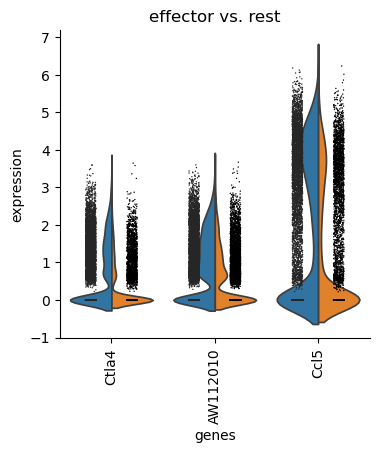

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:1328: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


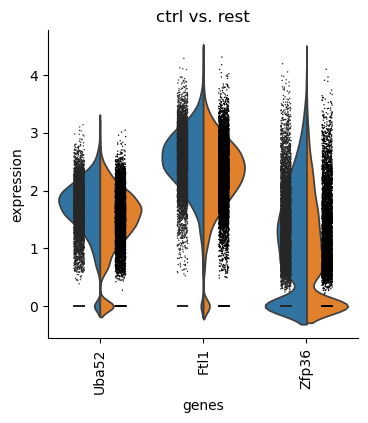

In [19]:
sc.pl.rank_genes_groups_violin(adata_filtered, groups=['effector', 'ctrl'], n_genes=3)


In [23]:
sc.tl.rank_genes_groups(
    adata_filtered, groupby="condition", method="wilcoxon", use_raw=False,  key_added="dea_condition"
)

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


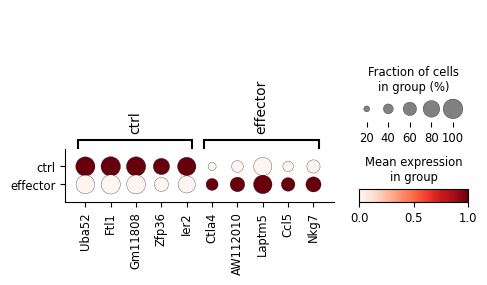

In [24]:
sc.tl.dendrogram(
    adata_filtered,
    groupby="condition",
)



In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata_filtered, groupby="condition", standard_scale="var", n_genes=10, key="dea_condition"
)

In [25]:
ranked_genes_df = sc.get.rank_genes_groups_df(
    adata_filtered, group=None, key="dea_condition"
)

In [26]:
ranked_genes_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ctrl,Uba52,24.787962,0.401105,1.208888e-135,5.421562e-132
1,ctrl,Ftl1,23.661572,0.398752,8.972378e-124,2.682591e-120
2,ctrl,Gm11808,20.378088,0.306237,2.616814e-92,2.607946e-89
3,ctrl,Zfp36,20.336294,0.684178,6.139815e-92,5.796955e-89
4,ctrl,Ier2,18.642664,0.485656,1.448472e-77,1.082672e-74
...,...,...,...,...,...,...
35873,effector,Ier2,-18.642664,-0.485656,1.448472e-77,1.082672e-74
35874,effector,Zfp36,-20.336294,-0.684178,6.139815e-92,5.796955e-89
35875,effector,Gm11808,-20.378088,-0.306237,2.616814e-92,2.607946e-89
35876,effector,Ftl1,-23.661572,-0.398752,8.972378e-124,2.682591e-120


In [27]:
import pandas as pd
import scanpy as sc

# 1. Fetch the raw ranked genes data frame from your specific analysis key
raw_df = sc.get.rank_genes_groups_df(adata_filtered, group=None, key="dea_condition")

# 2. Group by each cluster ('group') and grab the top 10 genes using .head(10)
# We use a lambda function to reset the index (0-9) so they line up perfectly
top10_df = (
    raw_df.groupby("group")["names"]
    .apply(lambda x: x.head(10).reset_index(drop=True))
    .unstack(level=0)
)

# 3. Clean up the DataFrame index name for a polished table
top10_df.index.name = "Rank"
top10_df.index = top10_df.index + 1  # Shifts index from 0-9 to 1-10


/tmp/ipykernel_3282116/227805212.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw_df.groupby("group")["names"]


In [28]:
top10_df

group,ctrl,effector
Rank,,
1,Uba52,Ctla4
2,Ftl1,AW112010
3,Gm11808,Laptm5
4,Zfp36,Ccl5
5,Ier2,Nkg7
6,Socs3,H2-D1
7,Tpt1,Emb
8,Socs1,H2-Q7
9,Klf2,Ifngr1


In [60]:
mdata_tumor = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [43]:
mdata_tumor["gex"].obs.group4

10mix-ICI1_AAACCTGAGAGCCTAG-1      ctrl
10mix-ICI1_AAACCTGAGATGTGGC-1      ctrl
10mix-ICI1_AAACCTGAGCCACGTC-1      ctrl
10mix-ICI1_AAACCTGAGGCTCTTA-1      ctrl
10mix-ICI1_AAACCTGAGGGCACTA-1      ctrl
                                   ... 
GF-ICI2-plus_TTTGTCATCCCTTGCA-1      GF
GF-ICI2-plus_TTTGTCATCGTTGCCT-1      GF
GF-ICI2-plus_TTTGTCATCTAACTGG-1      GF
GF-ICI2-plus_TTTGTCATCTCTGTCG-1      GF
GF-ICI2-plus_TTTGTCATCTGTTGAG-1      GF
Name: group4, Length: 72592, dtype: category
Categories (4, object): ['effector' < 'ctrl' < 'GF' < 'GF_noici']

In [44]:
# Slice and update the view properly
keep_conditions = ["ctrl", "effector"]
mdata_tumor.mod["gex"] = mdata_tumor.mod["gex"][mdata_tumor.mod["gex"].obs["group4"].isin(keep_conditions)].copy()
mdata_tumor.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [45]:
mdata_tumor["gex"].obs.group4.unique()

['ctrl', 'effector']
Categories (2, object): ['effector' < 'ctrl']

In [46]:
import scanpy as sc

# 1. Pull out your GEX layer if working inside MuData
# (If you are working on a standalone AnnData, just use your adata object directly)
adata_gex_tumor = mdata_tumor["gex"].copy()

# 2. Identify ribosomal genes (case-insensitive for safety, captures Rps, Rpl, RPS, RPL)
is_ribo = adata_gex_tumor.var_names.str.startswith(("Rps", "Rpl", "RPS", "RPL"))

# 3. Subset the object to EXCLUDE ribosomal genes from the expression matrix
# This removes them from the columns of adata.X so they cannot be ranked
adata_filtered_tumor = adata_gex_tumor[:, ~is_ribo].copy()

print(f"Removed {sum(is_ribo)} ribosomal genes.")
print(f"Remaining genes for ranking: {adata_filtered_tumor.shape[1]}")



Removed 99 ribosomal genes.
Remaining genes for ranking: 17482


In [47]:
sc.tl.rank_genes_groups(
    adata_filtered_tumor, groupby="group4", method="wilcoxon", use_raw=False,  key_added="dea_condition"
)

Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


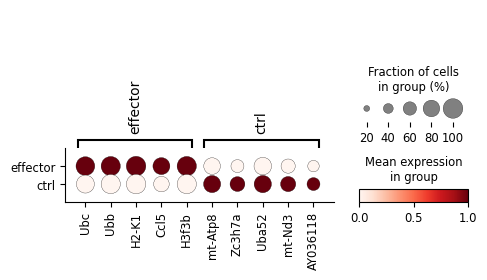

In [48]:
sc.tl.dendrogram(
    adata_filtered_tumor,
    groupby="group4",
)



Dendrogram not added. Dendrogram is added only when the number of categories to plot > 2


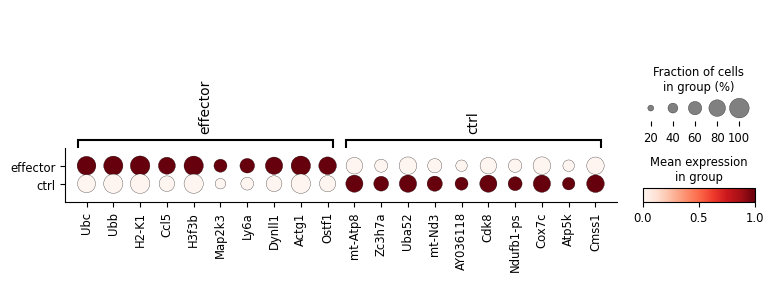

In [54]:
sc.pl.rank_genes_groups_dotplot(
    adata_filtered_tumor, groupby="group4", standard_scale="var", n_genes=10, key="dea_condition"
)

In [49]:
ranked_genes_df = sc.get.rank_genes_groups_df(
    adata_filtered_tumor, group=None, key="dea_condition"
)

In [50]:
ranked_genes_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,effector,Ubc,41.324554,0.478923,0.000000e+00,0.000000e+00
1,effector,Ubb,40.774982,0.279700,0.000000e+00,0.000000e+00
2,effector,H2-K1,32.920654,0.245245,1.113015e-237,3.891544e-234
3,effector,Ccl5,31.969141,0.836146,2.928643e-224,8.533090e-221
4,effector,H3f3b,30.341513,0.256961,3.251526e-202,8.120455e-199
...,...,...,...,...,...,...
34959,ctrl,H3f3b,-30.341513,-0.256961,3.251526e-202,8.120455e-199
34960,ctrl,Ccl5,-31.969141,-0.836146,2.928643e-224,8.533090e-221
34961,ctrl,H2-K1,-32.920654,-0.245245,1.113015e-237,3.891544e-234
34962,ctrl,Ubb,-40.774982,-0.279700,0.000000e+00,0.000000e+00


In [51]:
import pandas as pd
import scanpy as sc

# 1. Fetch the raw ranked genes data frame from your specific analysis key
raw_df = sc.get.rank_genes_groups_df(adata_filtered_tumor, group=None, key="dea_condition")

# 2. Group by each cluster ('group') and grab the top 10 genes using .head(10)
# We use a lambda function to reset the index (0-9) so they line up perfectly
top10_df = (
    raw_df.groupby("group")["names"]
    .apply(lambda x: x.head(10).reset_index(drop=True))
    .unstack(level=0)
)

# 3. Clean up the DataFrame index name for a polished table
top10_df.index.name = "Rank"
top10_df.index = top10_df.index + 1  # Shifts index from 0-9 to 1-10


/tmp/ipykernel_3282116/530256625.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw_df.groupby("group")["names"]


In [52]:
top10_df

group,effector,ctrl
Rank,,
1,Ubc,mt-Atp8
2,Ubb,Zc3h7a
3,H2-K1,Uba52
4,Ccl5,mt-Nd3
5,H3f3b,AY036118
6,Map2k3,Cdk8
7,Ly6a,Ndufb1-ps
8,Dynll1,Cox7c
9,Actg1,Atp5k


In [86]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import scipy.sparse
import seaborn as sns

# 1. Reference your GEX layer
adata = mdata["gex"]

# 2. Check if the gene exists in your dataset
if "Cxcr3" in adata.var_names:
    
    # Safely extract gene expression (handles both sparse and dense matrices)
    if scipy.sparse.issparse(adata.X):
        cxcr3_expr = adata[:, "Cxcr3"].X.toarray().flatten()
    else:
        cxcr3_expr = adata[:, "Cxcr3"].X.flatten()
    
    # 3. Create a temporary DataFrame for plotting
    plot_df = pd.DataFrame({
        "Expression": cxcr3_expr,
        "Condition": adata.obs["condition"]
    })
    
    # 4. Filter to keep only the "ctrl" and "effector" groups
    plot_df = plot_df[plot_df["Condition"].isin([ "effector","ctrl"])]
    
   

In [101]:
plot_df

,Expression,Condition
AAACCTGAGTCTTGCA-1_10mix1,0.000000,ctrl
AAACCTGAGTTAAGTG-1_10mix1,0.000000,ctrl
AAACCTGCAGGATCGA-1_10mix1,0.591710,ctrl
AAACCTGCATAACCTG-1_10mix1,0.000000,ctrl
AAACCTGCATACCATG-1_10mix1,0.839923,ctrl
...,...,...
TTTGTCAGTCTCGTTC-1_11mix2,0.000000,effector
TTTGTCATCGGATGGA-1_11mix2,0.000000,effector
TTTGTCATCTACCAGA-1_11mix2,0.000000,effector
TTTGTCATCTCCTATA-1_11mix2,0.000000,effector


In [102]:
# 1. Look at the whole population (including zeros)
print("--- Overall Population Breakdown (Including Zeros) ---")
print(plot_df.groupby("Condition")["Expression"].mean())

# 2. Look at the fraction of cells that actually express Cxcr3
print("\n--- Percentage of Cells Expressing Cxcr3 (%) ---")
pct_expressing = plot_df.groupby("Condition")["Expression"].apply(lambda x: (x > 0).mean() * 100)
print(pct_expressing)

# 3. Look only at active cells
print("\n--- Active Cell Expression Intensity (Excluding Zeros) ---")
print(plot_df[plot_df["Expression"] > 0].groupby("Condition")["Expression"].mean())

--- Overall Population Breakdown (Including Zeros) ---
Condition
GF               NaN
ctrl        0.125516
effector    0.171542
Name: Expression, dtype: float32

--- Percentage of Cells Expressing Cxcr3 (%) ---
Condition
GF                NaN
ctrl        16.009615
effector    21.286816
Name: Expression, dtype: float64

--- Active Cell Expression Intensity (Excluding Zeros) ---
Condition
GF               NaN
ctrl        0.784003
effector    0.805861
Name: Expression, dtype: float32


/tmp/ipykernel_3282116/907226582.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_df.groupby("Condition")["Expression"].mean())
/tmp/ipykernel_3282116/907226582.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct_expressing = plot_df.groupby("Condition")["Expression"].apply(lambda x: (x > 0).mean() * 100)
/tmp/ipykernel_3282116/907226582.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_df

In [95]:
# Keep only cells where Cxcr3 is greater than 0
expressing_cells_df = plot_df[plot_df["Expression"] > 0]
# Pass expressing_cells_df into your standard boxplot code

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

effector vs. ctrl: Mann-Whitney-Wilcoxon test two-sided, P_val:6.175e-16 U_stat=2.602e+07


/tmp/ipykernel_3282116/2799161866.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


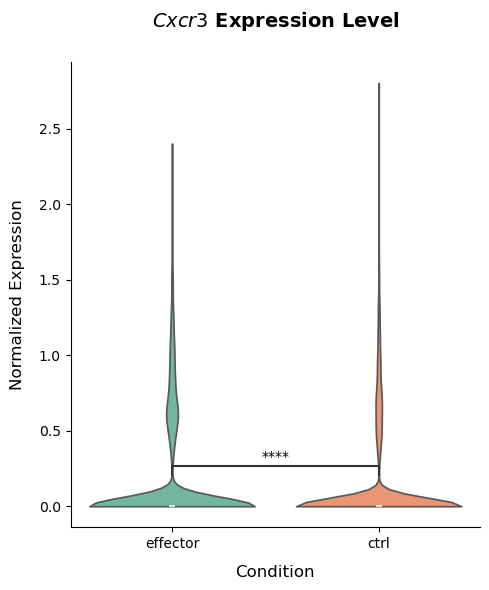

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

plt.figure(figsize=(5, 6))  # Slightly taller to accommodate the stats bar at the top

# 1. Build your core violin plot
ax = sns.violinplot(
    data=plot_df, 
    x="Condition", 
    y="Expression", 
    order=["effector","ctrl"],
    palette="Set2",
    inner="box",      
    cut=0             
)

# 2. Configure the statistical annotator
# Define the pair comparison you want to evaluate
pairs = [("effector","ctrl")]

annotator = Annotator(
    ax, 
    pairs, 
    data=plot_df, 
    x="Condition", 
    y="Expression", 
    order=["effector","ctrl"]
)

# Apply the non-parametric Mann-Whitney test
annotator.configure(
    test="Mann-Whitney", 
    text_format="star",    # Options: 'star' (e.g., ***) or 'simple' (e.g., p = 0.001)
    loc="inside"
)
annotator.apply_and_annotate()

# 3. Aesthetics and text formatting
plt.title("$Cxcr3$ Expression Level", fontsize=14, fontweight="bold", pad=25) # Extra padding for bracket
plt.xlabel("Condition", fontsize=12, labelpad=10)
plt.ylabel("Normalized Expression", fontsize=12, labelpad=10)
sns.despine()

plt.tight_layout()

# Save the final figure
#save_path = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/cxcr3_violin_stats.svg"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")
#plt.close()

In [89]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import scipy.sparse
import seaborn as sns

# 1. Reference your GEX layer
adata_tumor = mdata_tumor["gex"]

# 2. Check if the gene exists in your dataset
if "Cxcr3" in adata_tumor.var_names:
    
    # Safely extract gene expression (handles both sparse and dense matrices)
    if scipy.sparse.issparse(adata.X):
        cxcr3_expr = adata_tumor[:, "Cxcr3"].X.toarray().flatten()
    else:
        cxcr3_expr = adata_tumor[:, "Cxcr3"].X.flatten()
    
    # 3. Create a temporary DataFrame for plotting
    plot_df_tumor = pd.DataFrame({
        "Expression": cxcr3_expr,
        "group4": adata_tumor.obs["group4"]
    })
    
    # 4. Filter to keep only the "ctrl" and "effector" groups
    plot_df_tumor = plot_df_tumor[plot_df_tumor["group4"].isin(["effector","ctrl"])]
    
   

In [81]:
# Keep only cells where Cxcr3 is greater than 0
expressing_cells_df_tumor = plot_df_tumor[plot_df_tumor["Expression"] > 0]
# Pass expressing_cells_df into your standard boxplot code

/tmp/ipykernel_3282116/3179220116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

effector vs. ctrl: Mann-Whitney-Wilcoxon test two-sided, P_val:1.005e-217 U_stat=2.370e+08


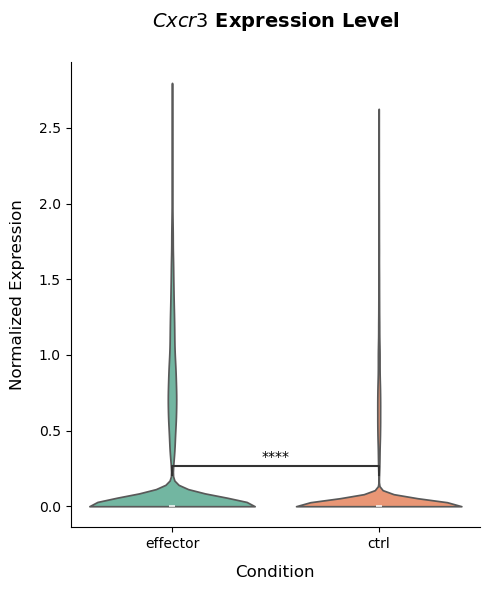

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

plt.figure(figsize=(5, 6))  # Slightly taller to accommodate the stats bar at the top

# 1. Build your core violin plot
ax = sns.violinplot(
    data=plot_df_tumor, 
    x="group4", 
    y="Expression", 
    order=["effector","ctrl"],
    palette="Set2",
    inner="box",      
    cut=0             
)

# 2. Configure the statistical annotator
# Define the pair comparison you want to evaluate
pairs = [("effector","ctrl")]

annotator = Annotator(
    ax, 
    pairs, 
    data=plot_df_tumor, 
    x="group4", 
    y="Expression", 
    order=["effector","ctrl"]
)

# Apply the non-parametric Mann-Whitney test
annotator.configure(
    test="Mann-Whitney", 
    text_format="star",    # Options: 'star' (e.g., ***) or 'simple' (e.g., p = 0.001)
    loc="inside"
)
annotator.apply_and_annotate()

# 3. Aesthetics and text formatting
plt.title("$Cxcr3$ Expression Level", fontsize=14, fontweight="bold", pad=25) # Extra padding for bracket
plt.xlabel("Condition", fontsize=12, labelpad=10)
plt.ylabel("Normalized Expression", fontsize=12, labelpad=10)
sns.despine()

plt.tight_layout()

# Save the final figure
#save_path = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/cxcr3_violin_stats.svg"
#plt.savefig(save_path, dpi=300, bbox_inches="tight")
#plt.close()

In [104]:
plot_df_tumor

,Expression,group4
10mix-ICI1_AAACCTGAGAGCCTAG-1,0.000000,ctrl
10mix-ICI1_AAACCTGAGATGTGGC-1,0.943146,ctrl
10mix-ICI1_AAACCTGAGCCACGTC-1,0.000000,ctrl
10mix-ICI1_AAACCTGAGGCTCTTA-1,0.000000,ctrl
10mix-ICI1_AAACCTGAGGGCACTA-1,0.000000,ctrl
...,...,...
11mix-ICI2_TTTGTCACATAGTAAG-1,0.995669,effector
11mix-ICI2_TTTGTCAGTCTGGTCG-1,0.000000,effector
11mix-ICI2_TTTGTCATCCTCAACC-1,0.000000,effector
11mix-ICI2_TTTGTCATCGCCCTTA-1,0.774827,effector


In [107]:
# 1. Look at the whole population (including zeros)
print("--- Overall Population Breakdown (Including Zeros) ---")
print(plot_df_tumor.groupby("group4")["Expression"].mean())

# 2. Look at the fraction of cells that actually express Cxcr3
print("\n--- Percentage of Cells Expressing Cxcr3 (%) ---")
pct_expressing = plot_df_tumor.groupby("group4")["Expression"].apply(lambda x: (x > 0).mean() * 100)
print(pct_expressing)

# 3. Look only at active cells
print("\n--- Active Cell Expression Intensity (Excluding Zeros) ---")
print(plot_df_tumor[plot_df_tumor["Expression"] > 0].groupby("group4")["Expression"].mean())

--- Overall Population Breakdown (Including Zeros) ---
group4
effector    0.217536
ctrl        0.102572
GF               NaN
GF_noici         NaN
Name: Expression, dtype: float32

--- Percentage of Cells Expressing Cxcr3 (%) ---
group4
effector    23.462486
ctrl        11.943857
GF                NaN
GF_noici          NaN
Name: Expression, dtype: float64

--- Active Cell Expression Intensity (Excluding Zeros) ---
group4
effector    0.927167
ctrl        0.858781
GF               NaN
GF_noici         NaN
Name: Expression, dtype: float32


/tmp/ipykernel_3282116/3407454960.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(plot_df_tumor.groupby("group4")["Expression"].mean())
/tmp/ipykernel_3282116/3407454960.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct_expressing = plot_df_tumor.groupby("group4")["Expression"].apply(lambda x: (x > 0).mean() * 100)
/tmp/ipykernel_3282116/3407454960.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prin